Loaded 192 rows
    Folder            File  f0_idx  H1_idx  H2_idx  H3_idx      f0_dB  \
0  1m_x_01  1m_x_01_02.mat   13108   26215   39323   52430 -65.587108   
1  1m_x_01  1m_x_01_04.mat   13108   26215   39323   52430 -59.269270   
2  1m_x_01  1m_x_01_06.mat   13108   26215   39323   52430 -55.865673   
3  1m_x_01  1m_x_01_08.mat   13108   26215   39323   52430 -53.531129   
4  1m_x_01  1m_x_01_10.mat   13108   26215   39323   52430 -51.499152   

       H1_dB      H2_dB      H3_dB  ...  H2_exceeds  H3_exceeds  U1_exceeds  \
0 -86.622995 -86.919761 -86.872702  ...           1           1           0   
1 -86.706138 -86.913674 -86.957970  ...           1           1           0   
2 -86.666725 -86.829723 -87.032513  ...           1           1           0   
3 -86.656676 -86.844538 -86.955780  ...           1           1           0   
4 -86.430586 -86.725906 -86.946998  ...           1           1           0   

   U2_exceeds  U3_exceeds  Unsafe_1s  Unsafe_2s  Unsafe_3s  Target_BB_

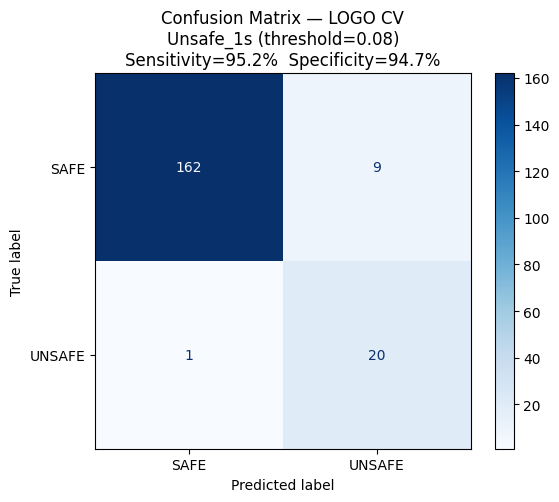


  AUC = 0.975


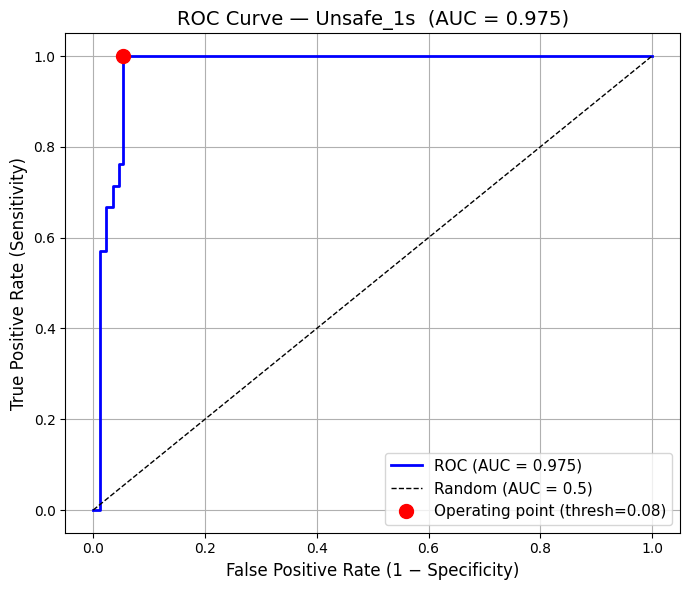


Retraining on all data for SHAP analysis


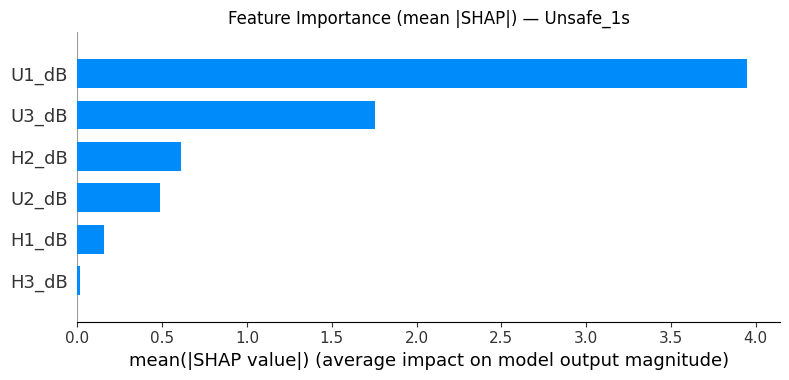

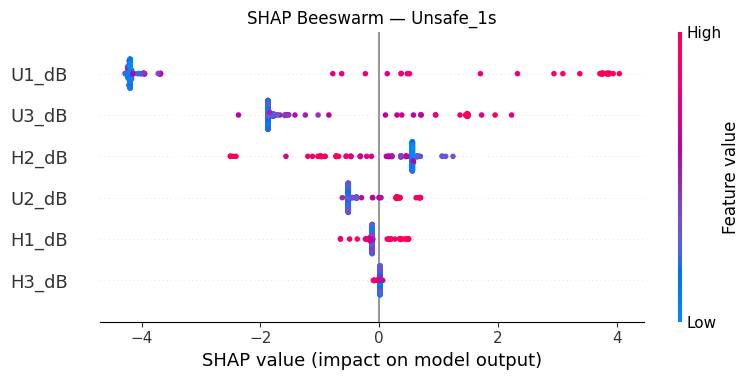

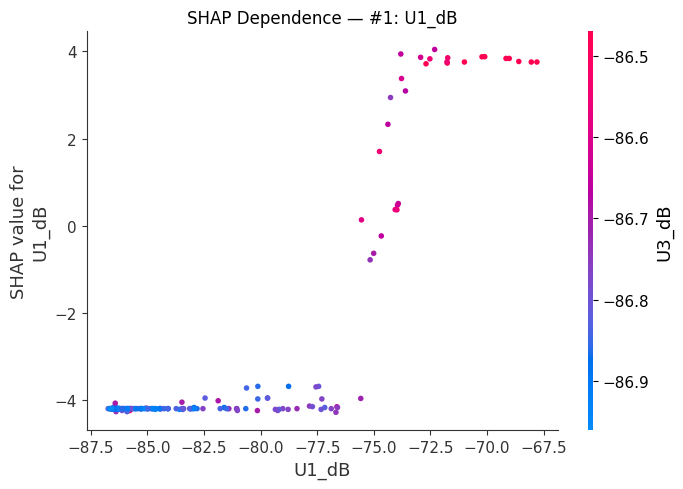

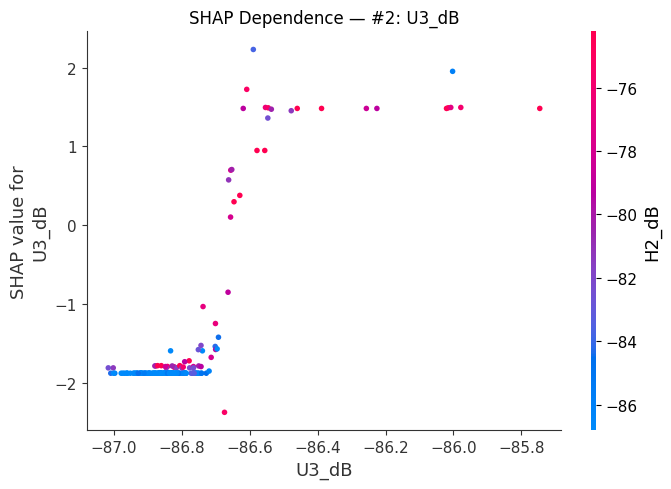

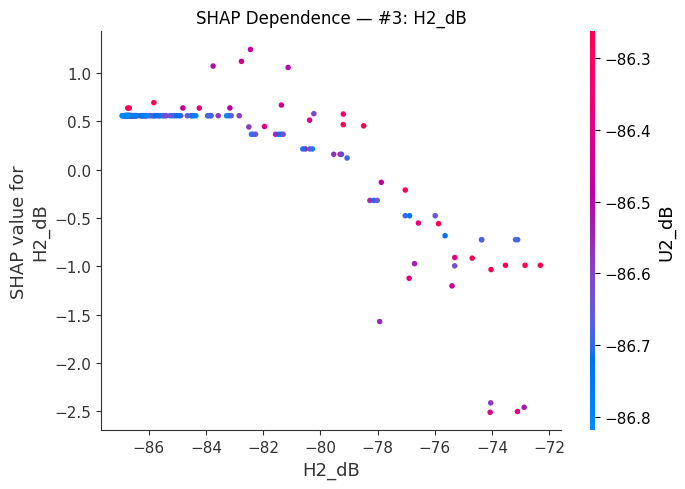


Feature Importance Ranking
Feature  Mean_Abs_SHAP  XGB_Gain
  U1_dB       3.946374  0.778513
  U3_dB       1.754817  0.060513
  H2_dB       0.611819  0.069441
  U2_dB       0.486136  0.032736
  H1_dB       0.156889  0.020901
  H3_dB       0.015726  0.037896

Done.
  Threshold:   0.08
  AUC:         0.975
  Sensitivity: 95.2%
  Specificity: 94.7%


In [7]:
# PCD: XGBoost model + shap analysis
# install shap
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import xgboost as xgb
import shap

# load csv
df = pd.read_csv('PCD_Harmonic_Features.csv')
print(f"Loaded {len(df)} rows")
print(df.head())

# define features & target
# taking out f0 and detection flags
feature_cols = [
    'H1_dB', 'H2_dB', 'H3_dB',
    'U1_dB', 'U2_dB', 'U3_dB',
]

target_col = 'Unsafe_1s'
THRESHOLD = 0.080  # tuned for high sensitivity

missing = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable: {list(df.columns)}")

X = df[feature_cols].copy()
y = df[target_col].astype(int)

bool_cols = [c for c in X.columns if X[c].dtype == bool]
X[bool_cols] = X[bool_cols].astype(int)

print(f"\nFeatures: {X.shape}")
print(f"Target: {target_col}")
print(f"Decision threshold: {THRESHOLD}")
print(f"Class distribution:\n  SAFE:   {(y==0).sum()}")
print(f"  UNSAFE: {(y==1).sum()}")
print(f"  Unsafe ratio: {y.mean():.1%}")

# leave one group out cross-validation
groups = df['Folder'].values
unique_groups = np.unique(groups)

print(f"\nGroups ({len(unique_groups)}):")
for g in unique_groups:
    mask = groups == g
    print(f"  {g}: {mask.sum()} files ({y[mask].sum()} unsafe)")

logo = LeaveOneGroupOut()

n_safe = (y == 0).sum()
n_unsafe = (y == 1).sum()
scale_pos = n_safe / max(n_unsafe, 1)

y_prob_cv = np.full(len(y), np.nan)

print(f"\n{'='*60}")
print("Leave-One-Group-Out Cross-Validation")
print(f"{'='*60}")

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    if y_train.nunique() < 2:
        group_name = np.unique(groups[test_idx])[0]
        print(f"  Fold {fold+1}: held out {group_name} — SKIPPED (one class in train)")
        y_prob_cv[test_idx] = y_train.mean()
        continue

    mdl = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=42,
    )
    mdl.fit(X_train, y_train)
    y_prob_cv[test_idx] = mdl.predict_proba(X_test)[:, 1]

    # Apply threshold
    preds = (y_prob_cv[test_idx] >= THRESHOLD).astype(int)
    group_name = np.unique(groups[test_idx])[0]
    n_caught = ((preds == 1) & (y_test.values == 1)).sum()
    n_unsafe_test = (y_test == 1).sum()
    acc = (preds == y_test.values).mean()
    print(f"  Fold {fold+1}: held out {group_name:12s}  "
          f"acc={acc:.1%}  caught {n_caught}/{n_unsafe_test} unsafe")

# model evaluation
valid = ~np.isnan(y_prob_cv)
y_v = y[valid].values
yprob_v = y_prob_cv[valid]
yp_v = (yprob_v >= THRESHOLD).astype(int)

print(f"\n{'='*60}")
print(f"Cross-Validation Results — {target_col} (threshold={THRESHOLD})")
print(f"{'='*60}")
print(classification_report(y_v, yp_v, target_names=['SAFE', 'UNSAFE'], zero_division=0))

cm = confusion_matrix(y_v, yp_v)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / max(tp + fn, 1)
specificity = tn / max(tn + fp, 1)
precision   = tp / max(tp + fp, 1)
accuracy    = (tp + tn) / (tp + tn + fp + fn)
f1          = 2*precision*sensitivity / max(precision + sensitivity, 1e-9)

print(f"  Accuracy:    {accuracy:.1%}")
print(f"  Sensitivity: {sensitivity:.1%}  (recall — catching unsafe)")
print(f"  Specificity: {specificity:.1%}  (correctly identifying safe)")
print(f"  Precision:   {precision:.1%}")
print(f"  F1 Score:    {f1:.1%}")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['SAFE', 'UNSAFE']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix — LOGO CV\n{target_col} (threshold={THRESHOLD})\n'
             f'Sensitivity={sensitivity:.1%}  Specificity={specificity:.1%}')
plt.tight_layout()
plt.show()

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_v, yprob_v)
roc_auc = auc(fpr, tpr)

# mark operating point on the ROC curve
op_idx = np.argmin(np.abs(thresholds - THRESHOLD))

print(f"\n  AUC = {roc_auc:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.plot(fpr[op_idx], tpr[op_idx], 'ro', markersize=10,
        label=f'Operating point (thresh={THRESHOLD})')
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(f'ROC Curve — {target_col}  (AUC = {roc_auc:.3f})', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.show()

# retrain on all data for shap
print(f"\n{'='*60}")
print("Retraining on all data for SHAP analysis")
print(f"{'='*60}")

mdl_full = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
)
mdl_full.fit(X, y)

# shap analysis
explainer = shap.TreeExplainer(mdl_full)
shap_values = explainer.shap_values(X)

# feature importance bar plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title(f'Feature Importance (mean |SHAP|) — {target_col}')
plt.tight_layout()
plt.show()

# feature importance beeswarm plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title(f'SHAP Beeswarm — {target_col}')
plt.tight_layout()
plt.show()

# dependence plots for top 3 features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]

for rank, feat_idx in enumerate(top3_idx):
    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(feat_idx, shap_values, X, show=False, ax=ax)
    plt.title(f'SHAP Dependence — #{rank+1}: {feature_cols[feat_idx]}')
    plt.tight_layout()
    plt.show()

# feature importance table
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': mean_abs_shap,
    'XGB_Gain': mdl_full.feature_importances_,
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print(f"\n{'='*60}")
print("Feature Importance Ranking")
print(f"{'='*60}")
print(importance_df.to_string(index=False))

# Save
importance_df.to_csv('PCD_Feature_Importance.csv', index=False)
mdl_full.save_model('pcd_xgboost_model.json')

print(f"\nDone.")
print(f"  Threshold:   {THRESHOLD}")
print(f"  AUC:         {roc_auc:.3f}")
print(f"  Sensitivity: {sensitivity:.1%}")
print(f"  Specificity: {specificity:.1%}")